# Logistic-regression experiments

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    RocCurveDisplay,
    confusion_matrix,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from url_phishing_classification.config import (
    ALL_ENGINEERED_FEATURES,
    COUNT_FEATURES,
    ENTROPY_FEATURES,
    LENGTH_FEATURES,
    NORM_ENTROPY_FEATURES,
    OPERATING_THRESHOLD,
    RATIO_FEATURES,
    RISK_SIGNAL_FEATURES,
    STRUCTURAL_FLAG_FEATURES,
)

In [2]:
pd.set_option("display.max_columns", None)

In [3]:
DATA_PATH = Path("../data/train_preprocessed.csv")
TARGET = "label"
RANDOM_STATE = 42
OUTER_CV_FOLDS = 5
INNER_CV_FOLDS = 3
C_VALUES = (0.1, 1.0, 10.0, 20.0)

## Define the experiments


In [4]:
BASE_STRUCTURAL_FEATURES = LENGTH_FEATURES + COUNT_FEATURES + RATIO_FEATURES + STRUCTURAL_FLAG_FEATURES

FEATURE_SETS = {
    "structural": BASE_STRUCTURAL_FEATURES,
    "structural_plus_risk": BASE_STRUCTURAL_FEATURES + RISK_SIGNAL_FEATURES,
    "structural_plus_entropy": BASE_STRUCTURAL_FEATURES + ENTROPY_FEATURES,
    "structural_plus_norm_entropy": BASE_STRUCTURAL_FEATURES + NORM_ENTROPY_FEATURES,
    "structural_plus_all_entropy": BASE_STRUCTURAL_FEATURES + ENTROPY_FEATURES + NORM_ENTROPY_FEATURES,
    "all_engineered": ALL_ENGINEERED_FEATURES,
}

EXPERIMENTS_TO_RUN = list(FEATURE_SETS)

EXPERIMENT_TO_REFIT = "all_engineered"

In [5]:
df = pd.read_csv(DATA_PATH)
y = df[TARGET].astype(int)

## Run and track experiments

In [ ]:
def make_pipeline():
    """Pipeline for logistic regression."""
    return Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("logistic_regression", LogisticRegression(solver="liblinear", max_iter=2_000, random_state=RANDOM_STATE)),
        ]
    )


def threshold_metrics(y_true, probabilities, threshold=OPERATING_THRESHOLD):
    """Return a dictionary of metrics for a given threshold."""
    predictions = (np.asarray(probabilities) >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, predictions, labels=[0, 1]).ravel()
    return {
        "threshold": threshold,
        "recall": recall_score(y_true, predictions, zero_division=0),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "false_negative_rate": fn / (fn + tp) if fn + tp else np.nan,
        "false_positive_rate": fp / (fp + tn) if fp + tn else np.nan,
        "roc_auc": roc_auc_score(y_true, probabilities),
        "true_positives": tp,
        "false_positives": fp,
        "true_negatives": tn,
        "false_negatives": fn,
    }


def run_experiment(name, features, frame, target, threshold=OPERATING_THRESHOLD):
    """Return leakage-resistant out-of-fold predictions and one experiment record."""
    X = frame.loc[:, features].apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
    outer_cv = StratifiedKFold(n_splits=OUTER_CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    oof_probabilities = np.empty(len(target))
    selected_cs, inner_auc_scores = [], []

    for train_index, validation_index in outer_cv.split(X, target):
        inner_cv = StratifiedKFold(n_splits=INNER_CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
        search = GridSearchCV(
            make_pipeline(),
            param_grid={"logistic_regression__C": C_VALUES},
            scoring="roc_auc",
            cv=inner_cv,
            n_jobs=-1,
            refit=True,
        )
        search.fit(X.iloc[train_index], target.iloc[train_index])
        oof_probabilities[validation_index] = search.predict_proba(X.iloc[validation_index])[:, 1]
        selected_cs.append(search.best_params_["logistic_regression__C"])
        inner_auc_scores.append(search.best_score_)

    metrics = threshold_metrics(target, oof_probabilities, threshold=threshold)
    record = {
        "experiment": name,
        "feature_count": len(features),
        "features": tuple(features),
        "inner_cv_roc_auc_mean": np.mean(inner_auc_scores),
        "selected_C_by_outer_fold": tuple(selected_cs),
    }
    return record | metrics, oof_probabilities

In [7]:
# threshold = 0.5, mostly in line with training balance
THRESHOLD = 0.5

experiment_records, oof_predictions = [], {}
for experiment, features in FEATURE_SETS.items():
    record, probabilities = run_experiment(experiment, features, df, y, threshold=THRESHOLD)
    experiment_records.append(record)
    oof_predictions[experiment] = probabilities

experiment_results = pd.DataFrame(experiment_records).sort_values("roc_auc", ascending=False).reset_index(drop=True)
experiment_results

,experiment,feature_count,features,inner_cv_roc_auc_mean,selected_C_by_outer_fold,threshold,recall,precision,false_negative_rate,false_positive_rate,roc_auc,true_positives,false_positives,true_negatives,false_negatives
0,all_engineered,44,"(url_length, hostname_length, domain_length, s...",0.907507,"(20.0, 20.0, 20.0, 20.0, 20.0)",0.5,0.804326,0.840267,0.195674,0.146112,0.908245,3272,622,3635,796
1,structural_plus_risk,32,"(url_length, hostname_length, domain_length, s...",0.897213,"(20.0, 20.0, 20.0, 20.0, 20.0)",0.5,0.769912,0.851550,0.230088,0.128259,0.898523,3132,546,3711,936
2,structural_plus_all_entropy,40,"(url_length, hostname_length, domain_length, s...",0.892883,"(20.0, 20.0, 20.0, 20.0, 20.0)",0.5,0.793265,0.820911,0.206735,0.165375,0.893623,3227,704,3553,841
3,structural_plus_norm_entropy,34,"(url_length, hostname_length, domain_length, s...",0.890641,"(20.0, 20.0, 20.0, 20.0, 20.0)",0.5,0.776057,0.826007,0.223943,0.156213,0.891819,3157,665,3592,911
4,structural_plus_entropy,34,"(url_length, hostname_length, domain_length, s...",0.888224,"(20.0, 20.0, 20.0, 20.0, 20.0)",0.5,0.781711,0.821281,0.218289,0.162556,0.889096,3180,692,3565,888
5,structural,28,"(url_length, hostname_length, domain_length, s...",0.881688,"(20.0, 20.0, 20.0, 10.0, 20.0)",0.5,0.752950,0.828510,0.247050,0.148931,0.882771,3063,634,3623,1005


With threshold 0.5 recall and precision are balanced, with all_engineered features they are 0.80 and 0.84 respectively

In [8]:
# threshold = 0.95, adjusted to reduce false positives, due to very different deployment balance

experiment_records, oof_predictions = [], {}
for experiment, features in FEATURE_SETS.items():
    record, probabilities = run_experiment(experiment, features, df, y, threshold=OPERATING_THRESHOLD)
    experiment_records.append(record)
    oof_predictions[experiment] = probabilities

experiment_results = pd.DataFrame(experiment_records).sort_values("roc_auc", ascending=False).reset_index(drop=True)
experiment_results

,experiment,feature_count,features,inner_cv_roc_auc_mean,selected_C_by_outer_fold,threshold,recall,precision,false_negative_rate,false_positive_rate,roc_auc,true_positives,false_positives,true_negatives,false_negatives
0,all_engineered,44,"(url_length, hostname_length, domain_length, s...",0.907507,"(20.0, 20.0, 20.0, 20.0, 20.0)",0.95,0.359145,0.977912,0.640855,0.007752,0.908245,1461,33,4224,2607
1,structural_plus_risk,32,"(url_length, hostname_length, domain_length, s...",0.897213,"(20.0, 20.0, 20.0, 20.0, 20.0)",0.95,0.348820,0.981328,0.651180,0.006342,0.898523,1419,27,4230,2649
2,structural_plus_all_entropy,40,"(url_length, hostname_length, domain_length, s...",0.892883,"(20.0, 20.0, 20.0, 20.0, 20.0)",0.95,0.289823,0.979236,0.710177,0.005873,0.893623,1179,25,4232,2889
3,structural_plus_norm_entropy,34,"(url_length, hostname_length, domain_length, s...",0.890641,"(20.0, 20.0, 20.0, 20.0, 20.0)",0.95,0.282448,0.977041,0.717552,0.006342,0.891819,1149,27,4230,2919
4,structural_plus_entropy,34,"(url_length, hostname_length, domain_length, s...",0.888224,"(20.0, 20.0, 20.0, 20.0, 20.0)",0.95,0.285398,0.978921,0.714602,0.005873,0.889096,1161,25,4232,2907
5,structural,28,"(url_length, hostname_length, domain_length, s...",0.881688,"(20.0, 20.0, 20.0, 10.0, 20.0)",0.95,0.288348,0.973444,0.711652,0.007517,0.882771,1173,32,4225,2895


With threshold of 0.95 recall drops to 0.36 and precision increases to 0.98

## Compare performance



In [9]:
metric_columns = ["recall", "precision", "false_negative_rate", "false_positive_rate", "roc_auc"]
display_columns = (
    ["experiment", "feature_count", "threshold"]
    + metric_columns
    + [
        "inner_cv_roc_auc_mean",
        "selected_C_by_outer_fold",
    ]
)
experiment_results[display_columns].round(3)

,experiment,feature_count,threshold,recall,precision,false_negative_rate,false_positive_rate,roc_auc,inner_cv_roc_auc_mean,selected_C_by_outer_fold
0,all_engineered,44,0.95,0.359,0.978,0.641,0.008,0.908,0.908,"(20.0, 20.0, 20.0, 20.0, 20.0)"
1,structural_plus_risk,32,0.95,0.349,0.981,0.651,0.006,0.899,0.897,"(20.0, 20.0, 20.0, 20.0, 20.0)"
2,structural_plus_all_entropy,40,0.95,0.290,0.979,0.710,0.006,0.894,0.893,"(20.0, 20.0, 20.0, 20.0, 20.0)"
3,structural_plus_norm_entropy,34,0.95,0.282,0.977,0.718,0.006,0.892,0.891,"(20.0, 20.0, 20.0, 20.0, 20.0)"
4,structural_plus_entropy,34,0.95,0.285,0.979,0.715,0.006,0.889,0.888,"(20.0, 20.0, 20.0, 20.0, 20.0)"
5,structural,28,0.95,0.288,0.973,0.712,0.008,0.883,0.882,"(20.0, 20.0, 20.0, 10.0, 20.0)"


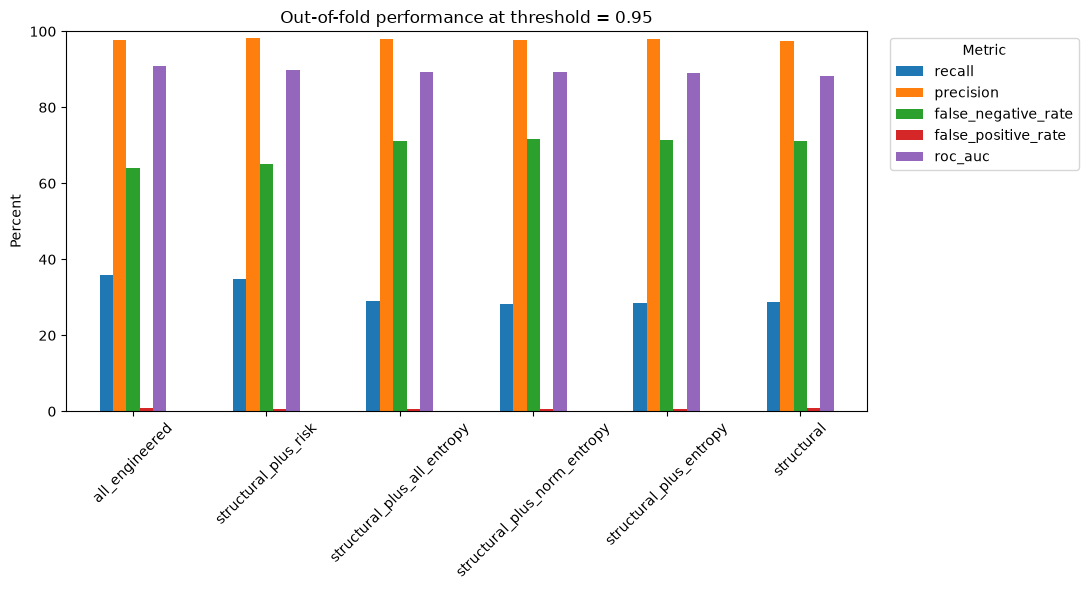

In [10]:
plot_data = experiment_results.set_index("experiment")[metric_columns].mul(100)
ax = plot_data.plot.bar(figsize=(11, 6), rot=0)
ax.set(title=f"Out-of-fold performance at threshold = {OPERATING_THRESHOLD:.2f}", ylabel="Percent", xlabel="")
ax.set_ylim(0, 100)
ax.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
for tick in ax.get_xticklabels():
    tick.set_rotation(45)

plt.tight_layout()

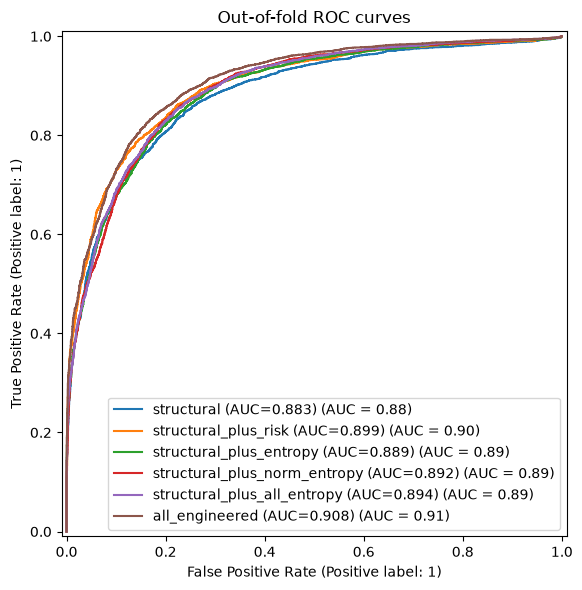

In [11]:
fig, ax = plt.subplots(figsize=(7, 6))
for experiment, probabilities in oof_predictions.items():
    auc = experiment_results.loc[experiment_results["experiment"] == experiment, "roc_auc"].iloc[0]
    RocCurveDisplay.from_predictions(y, probabilities, name=f"{experiment} (AUC={auc:.3f})", ax=ax)
ax.set_title("Out-of-fold ROC curves")
plt.tight_layout()

## Select hyperparameter (regularization) for the chosen feature set


In [12]:
refit_features = FEATURE_SETS[EXPERIMENT_TO_REFIT]
X_refit = df.loc[:, refit_features].apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
refit_cv = StratifiedKFold(n_splits=INNER_CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
final_search = GridSearchCV(
    make_pipeline(),
    param_grid={"logistic_regression__C": C_VALUES},
    scoring="roc_auc",
    cv=refit_cv,
    n_jobs=-1,
    refit=False,
)
final_search.fit(X_refit, y)
selected_C = final_search.best_params_["logistic_regression__C"]

print(f"Chosen experiment: {EXPERIMENT_TO_REFIT}")
print(f"Features: {len(refit_features)} | selected C: {selected_C}")
print(f"CV ROC-AUC used for C selection: {final_search.best_score_:.3f}")

Chosen experiment: all_engineered
Features: 44 | selected C: 20.0
CV ROC-AUC used for C selection: 0.908


## Inspect deployment-adjusted precision and recall

In [13]:
THRESHOLD_CV_FOLDS = 5
deployment_prevalence = 0.001  # approx one 1 URL per 1,000 incoming URLs

In [14]:
threshold_cv = StratifiedKFold(n_splits=THRESHOLD_CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
oof_probabilities_for_threshold = np.empty(len(y))

for train_index, validation_index in threshold_cv.split(X_refit, y):
    fold_model = make_pipeline().set_params(logistic_regression__C=selected_C)
    fold_model.fit(X_refit.iloc[train_index], y.iloc[train_index])
    oof_probabilities_for_threshold[validation_index] = fold_model.predict_proba(X_refit.iloc[validation_index])[:, 1]

print(f"Generated {THRESHOLD_CV_FOLDS}-fold OOF probabilities using fixed C={selected_C}.")
print(f"OOF ROC-AUC: {roc_auc_score(y, oof_probabilities_for_threshold):.3f}")

Generated 5-fold OOF probabilities using fixed C=20.0.
OOF ROC-AUC: 0.908


In [15]:
threshold_grid = np.linspace(0.0, 1.0, 101)
threshold_results = pd.DataFrame(
    [threshold_metrics(y, oof_probabilities_for_threshold, threshold) for threshold in threshold_grid]
).rename(columns={"false_positive_rate": "fpr"})

denominator = threshold_results["recall"] * deployment_prevalence + threshold_results["fpr"] * (
    1 - deployment_prevalence
)
threshold_results["deployment_precision"] = np.divide(
    threshold_results["recall"] * deployment_prevalence,
    denominator,
    out=np.full(len(threshold_results), np.nan),
    where=denominator > 0,
)

n_urls = 100_000
expected_phishing = n_urls * deployment_prevalence
expected_legitimate = n_urls * (1 - deployment_prevalence)
representative_thresholds = [0.50, 0.80, 0.90, 0.95, 0.98]
threshold_table = pd.DataFrame(
    [threshold_metrics(y, oof_probabilities_for_threshold, threshold) for threshold in representative_thresholds]
).rename(columns={"false_positive_rate": "fpr"})
threshold_table["expected_deployment_precision"] = (
    threshold_table["recall"]
    * deployment_prevalence
    / (threshold_table["recall"] * deployment_prevalence + threshold_table["fpr"] * (1 - deployment_prevalence))
)
threshold_table["true_phishing_urls_caught_per_100000"] = expected_phishing * threshold_table["recall"]
threshold_table["legitimate_urls_falsely_flagged_per_100000"] = expected_legitimate * threshold_table["fpr"]

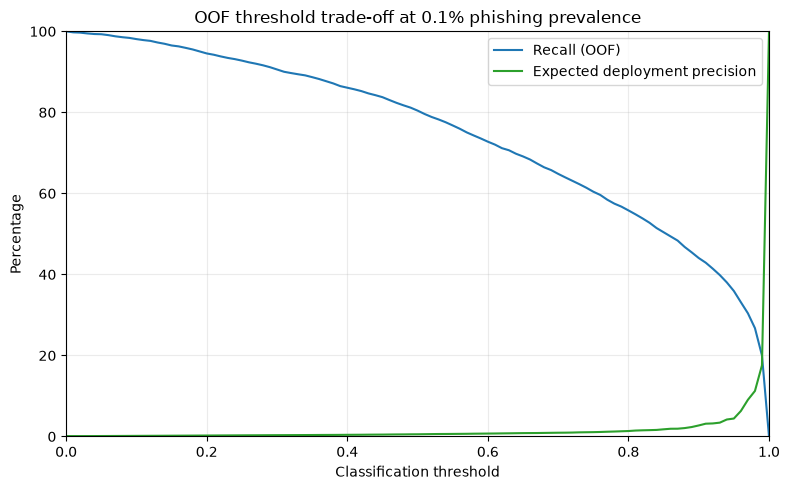

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(threshold_results["threshold"], threshold_results["recall"] * 100, label="Recall (OOF)")
ax.plot(
    threshold_results["threshold"],
    threshold_results["deployment_precision"] * 100,
    color="tab:green",
    label="Expected deployment precision",
)
ax.set(
    title="OOF threshold trade-off at 0.1% phishing prevalence",
    xlabel="Classification threshold",
    ylabel="Percentage",
    xlim=(0, 1),
    ylim=(0, 100),
)
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()

### Representative thresholds


In [17]:
threshold_table[
    [
        "threshold",
        "recall",
        "fpr",
        "expected_deployment_precision",
        "true_phishing_urls_caught_per_100000",
        "legitimate_urls_falsely_flagged_per_100000",
    ]
].round(4)

,threshold,recall,fpr,expected_deployment_precision,true_phishing_urls_caught_per_100000,legitimate_urls_falsely_flagged_per_100000
0,0.50,0.8043,0.1461,0.0055,80.4326,14596.6173
1,0.80,0.5580,0.0409,0.0135,55.8014,4083.2981
2,0.90,0.4405,0.0157,0.0273,44.0511,1572.3044
3,0.95,0.3591,0.0078,0.0443,35.9145,774.4186
4,0.98,0.2675,0.0021,0.1124,26.7453,211.2051


I would choose a threshold at 0.95, since with that still more than a third of the phishing URLs are caught, but false positive rate is below 10%, at 7.8%. These numbers are far from good but that's how I would make the trade-off between the two with the deployment prevalence at 0.1%.